In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
df = pd.read_csv('/content/data.csv', sep=';')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")


Number of rows: 4424
Number of columns: 37

Column Names:
1. Marital status
2. Application mode
3. Application order
4. Course
5. Daytime/evening attendance	
6. Previous qualification
7. Previous qualification (grade)
8. Nacionality
9. Mother's qualification
10. Father's qualification
11. Mother's occupation
12. Father's occupation
13. Admission grade
14. Displaced
15. Educational special needs
16. Debtor
17. Tuition fees up to date
18. Gender
19. Scholarship holder
20. Age at enrollment
21. International
22. Curricular units 1st sem (credited)
23. Curricular units 1st sem (enrolled)
24. Curricular units 1st sem (evaluations)
25. Curricular units 1st sem (approved)
26. Curricular units 1st sem (grade)
27. Curricular units 1st sem (without evaluations)
28. Curricular units 2nd sem (credited)
29. Curricular units 2nd sem (enrolled)
30. Curricular units 2nd sem (evaluations)
31. Curricular units 2nd sem (approved)
32. Curricular units 2nd sem (grade)
33. Curricular units 2nd sem (without 

In [7]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nTarget Classes:")
print(df['Target'].value_counts())

Missing values: 0
Duplicate rows: 0

Data Types:
int64      29
float64     7
object      1
Name: count, dtype: int64

Target Classes:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [8]:
df.columns = df.columns.str.strip()

print("Column names cleaned successfully!")

Column names cleaned successfully!


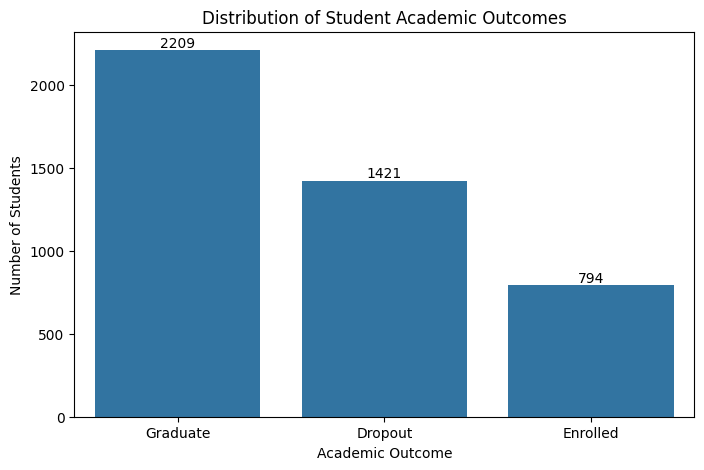

In [9]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Target',
    order=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Distribution of Student Academic Outcomes')
plt.xlabel('Academic Outcome')
plt.ylabel('Number of Students')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation
The dataset is moderately imbalanced. Graduate students represent the largest group with 2,209 observations, followed by 1,421 dropout students and 794 enrolled students. Therefore, model performance should not be evaluated using accuracy alone. Precision, recall, F1-score, and confusion matrices will also be considered.


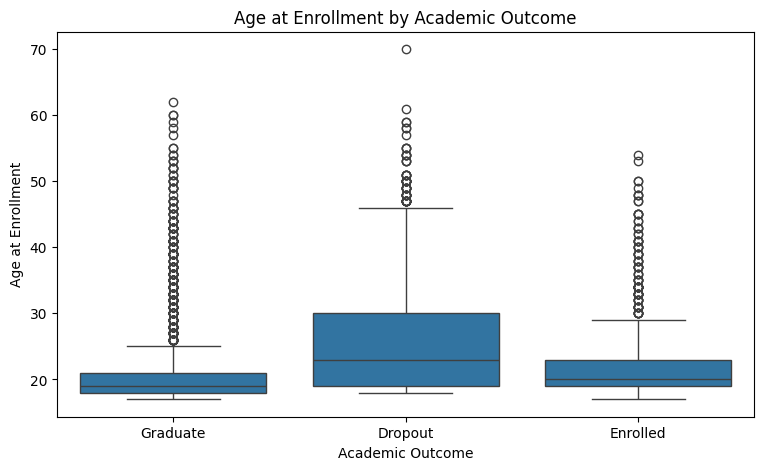

In [13]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Target',
    y='Age at enrollment',
    order=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Age at Enrollment by Academic Outcome')
plt.xlabel('Academic Outcome')
plt.ylabel('Age at Enrollment')

plt.show()

### Observation
This visualization compares the age distributions of students across the three academic outcomes. Differences in the median age and spread may indicate whether age at enrollment is associated with the likelihood of graduation or dropout.

### Observation
Students who dropped out tended to enroll at an older age than students who graduated or remained enrolled. The dropout group also shows a wider age distribution. This suggests that age at enrollment may contain useful information for predicting academic outcomes, although age alone cannot determine whether a student will drop out.

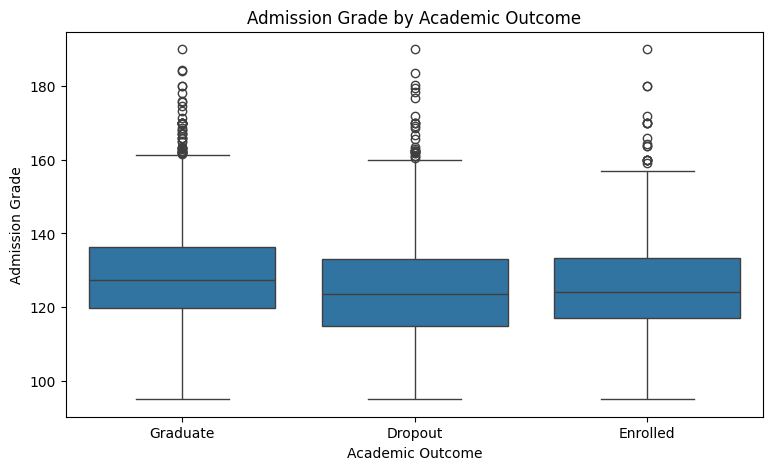

In [14]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Target',
    y='Admission grade',
    order=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Admission Grade by Academic Outcome')
plt.xlabel('Academic Outcome')
plt.ylabel('Admission Grade')

plt.show()

### Observation
Graduates have a slightly higher median admission grade than dropout and enrolled students. However, the distributions overlap substantially across all three groups. Therefore, admission grade appears to have some relationship with academic outcome, but it is unlikely to be a strong predictor when used alone.

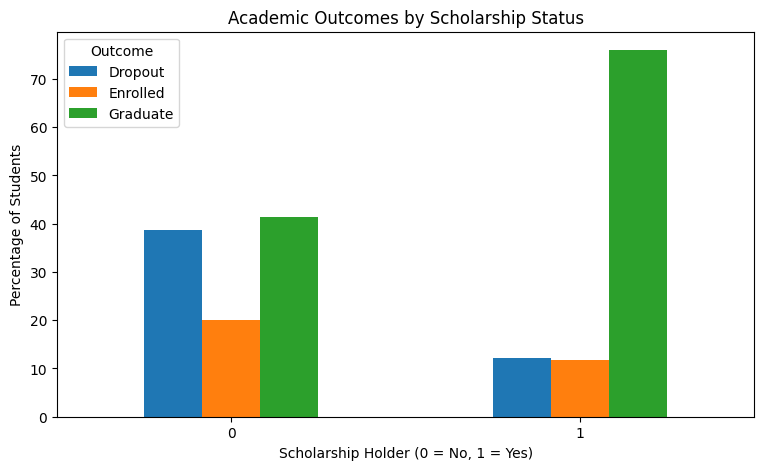

In [15]:
scholarship_table = pd.crosstab(
    df['Scholarship holder'],
    df['Target'],
    normalize='index'
) * 100

scholarship_table.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Academic Outcomes by Scholarship Status')
plt.xlabel('Scholarship Holder (0 = No, 1 = Yes)')
plt.ylabel('Percentage of Students')
plt.xticks(rotation=0)
plt.legend(title='Outcome')

plt.show()

### Observation
Scholarship status shows a noticeable relationship with academic outcomes. Among scholarship holders, approximately three-quarters of students graduated, while the dropout proportion was much lower. Students without scholarships had a substantially higher dropout percentage. This suggests that scholarship status may be an informative feature for predicting student outcomes.

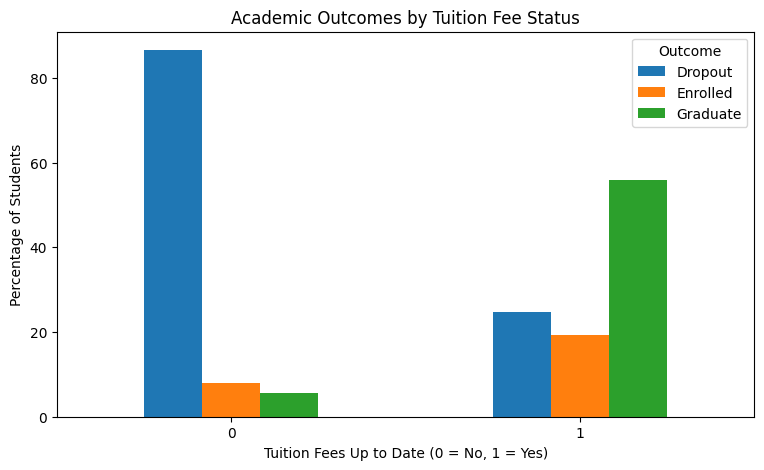

In [16]:
tuition_table = pd.crosstab(
    df['Tuition fees up to date'],
    df['Target'],
    normalize='index'
) * 100

tuition_table.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Academic Outcomes by Tuition Fee Status')
plt.xlabel('Tuition Fees Up to Date (0 = No, 1 = Yes)')
plt.ylabel('Percentage of Students')
plt.xticks(rotation=0)
plt.legend(title='Outcome')

plt.show()

### Observation
Tuition fee status shows a striking association with academic outcomes. Among students whose tuition fees were not up to date, the large majority dropped out. In contrast, students with up-to-date tuition payments were much more likely to graduate. This suggests that tuition fee status may be one of the strongest predictors of student dropout in the dataset.

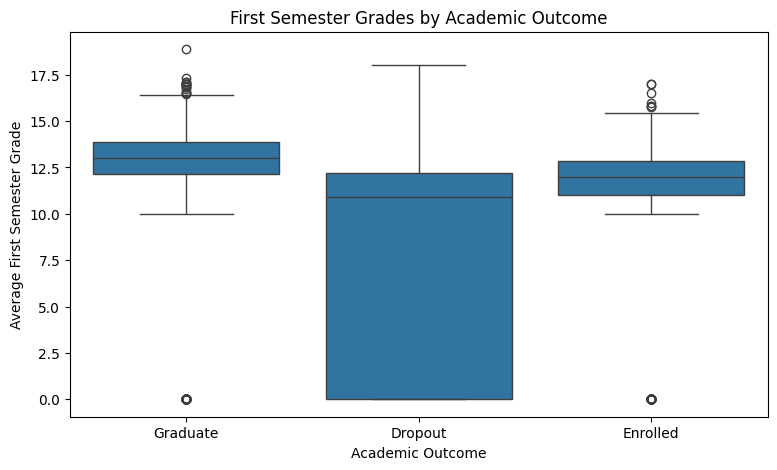

In [17]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 1st sem (grade)',
    order=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('First Semester Grades by Academic Outcome')
plt.xlabel('Academic Outcome')
plt.ylabel('Average First Semester Grade')

plt.show()

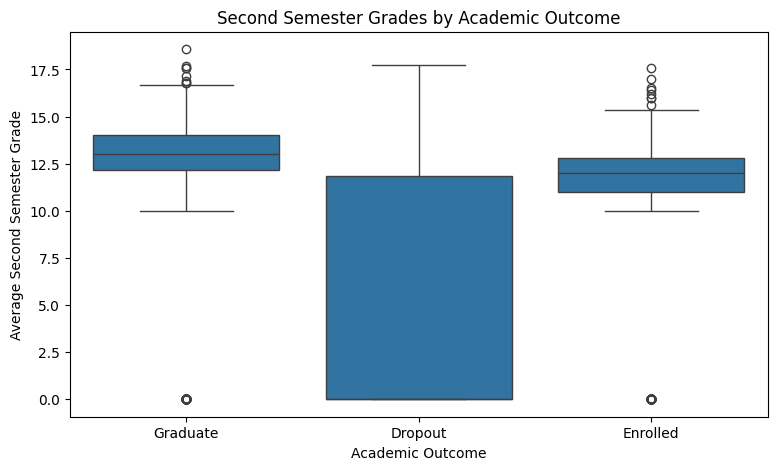

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 2nd sem (grade)',
    order=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Second Semester Grades by Academic Outcome')
plt.xlabel('Academic Outcome')
plt.ylabel('Average Second Semester Grade')

plt.show()

### Observation: Semester Grades
Academic performance shows a clear relationship with student outcomes. Graduates achieved higher and more consistent first- and second-semester grades, while the dropout group had substantially lower grades and much greater variability. A notable portion of dropout students recorded average semester grades of zero. Enrolled students generally fell between graduates and dropouts. These patterns suggest that early academic performance may be highly informative for predicting student outcomes.

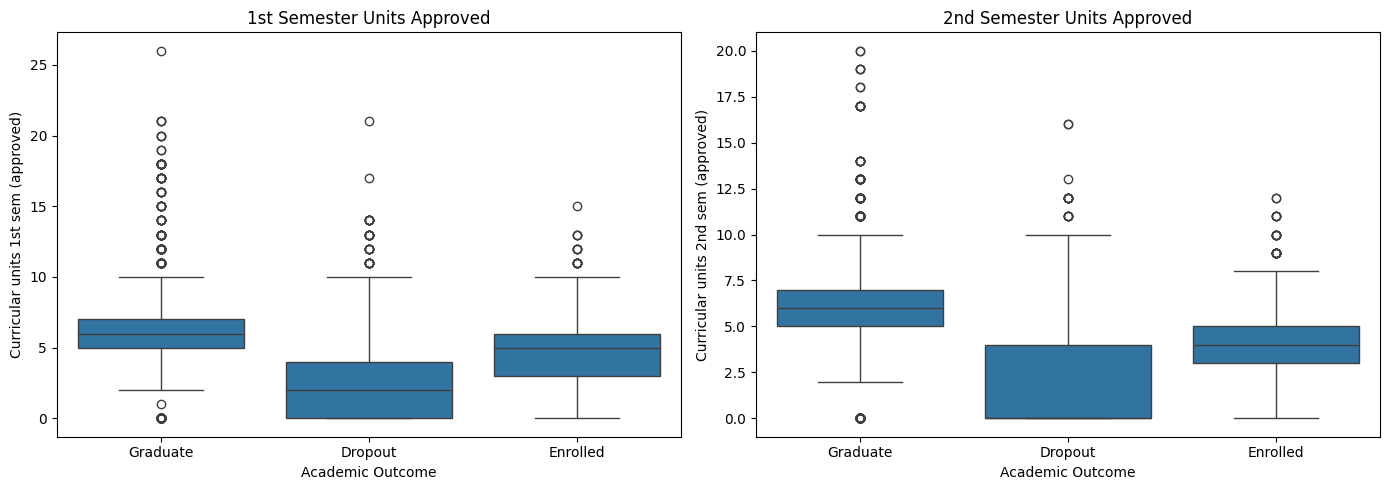

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 1st sem (approved)',
    order=['Graduate', 'Dropout', 'Enrolled'],
    ax=axes[0]
)

axes[0].set_title('1st Semester Units Approved')
axes[0].set_xlabel('Academic Outcome')

sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 2nd sem (approved)',
    order=['Graduate', 'Dropout', 'Enrolled'],
    ax=axes[1]
)

axes[1].set_title('2nd Semester Units Approved')
axes[1].set_xlabel('Academic Outcome')

plt.tight_layout()
plt.show()

### Observation: Curricular Units Approved
Graduates successfully completed substantially more curricular units in both semesters than students who dropped out. The dropout group had a much lower median number of approved units, with many students completing no units. The difference becomes particularly noticeable in the second semester. This suggests that the number of successfully completed courses may be one of the strongest indicators of academic outcome.

In [20]:
target_mapping = {
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
}

df_corr = df.copy()
df_corr['Target_encoded'] = df_corr['Target'].map(target_mapping)

print(df_corr[['Target', 'Target_encoded']].head(10))

     Target  Target_encoded
0   Dropout               0
1  Graduate               2
2   Dropout               0
3  Graduate               2
4  Graduate               2
5  Graduate               2
6  Graduate               2
7   Dropout               0
8  Graduate               2
9   Dropout               0


In [21]:
correlations = (
    df_corr
    .drop(columns=['Target'])
    .corr()['Target_encoded']
    .drop('Target_encoded')
    .sort_values()
)

print("10 Most Negative Correlations:")
print(correlations.head(10))

print("\n10 Most Positive Correlations:")
print(correlations.tail(10))

10 Most Negative Correlations:
Age at enrollment                                -0.243438
Debtor                                           -0.240999
Gender                                           -0.229270
Application mode                                 -0.221747
Curricular units 2nd sem (without evaluations)   -0.094028
Marital status                                   -0.089804
Curricular units 1st sem (without evaluations)   -0.068702
Previous qualification                           -0.056039
Mother's qualification                           -0.043178
Inflation rate                                   -0.026874
Name: Target_encoded, dtype: float64

10 Most Positive Correlations:
Displaced                              0.113986
Admission grade                        0.120889
Curricular units 1st sem (enrolled)    0.155974
Curricular units 2nd sem (enrolled)    0.175847
Scholarship holder                     0.297595
Tuition fees up to date                0.409827
Curricular units 1st s

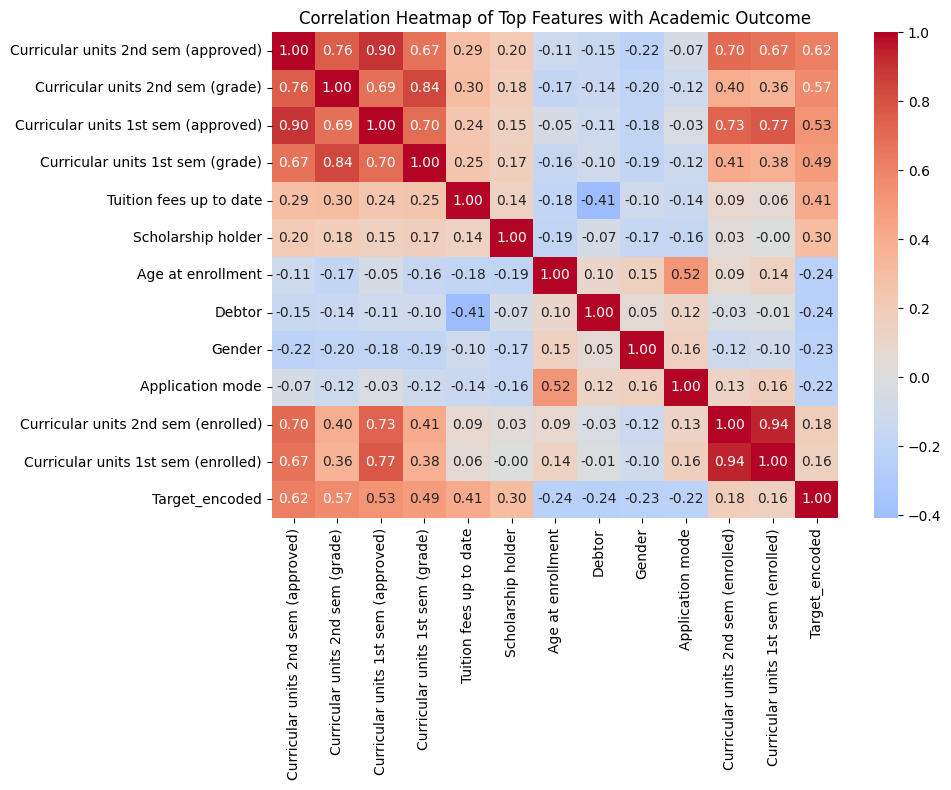

In [22]:
top_features = correlations.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_corr[list(top_features) + ['Target_encoded']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Top Features with Academic Outcome')
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation analysis reinforces the patterns observed during exploratory data analysis. Academic performance variables show the strongest positive relationships with academic outcome. In particular, second-semester curricular units approved has the strongest correlation (0.62), followed by second-semester grade (0.57), first-semester units approved (0.53), and first-semester grade (0.49).

Tuition fee status also shows a notable positive relationship (0.41). In contrast, age at enrollment and debtor status show negative associations with academic outcome.

These results suggest that academic progress, financial standing, and selected student characteristics may all contribute useful information for predicting student outcomes.

In [23]:
X = df.drop(columns=['Target'])
y = df['Target']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (4424, 36)
Target shape: (4424,)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 3539
Testing samples: 885

Training class distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Testing class distribution:
Target
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (3539, 36)
Testing data shape: (885, 36)


In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [27]:
log_accuracy = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred, average='macro')

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy: {log_accuracy:.4f}")
print(f"Macro F1 Score: {log_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.7684
Macro F1 Score: 0.6826

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



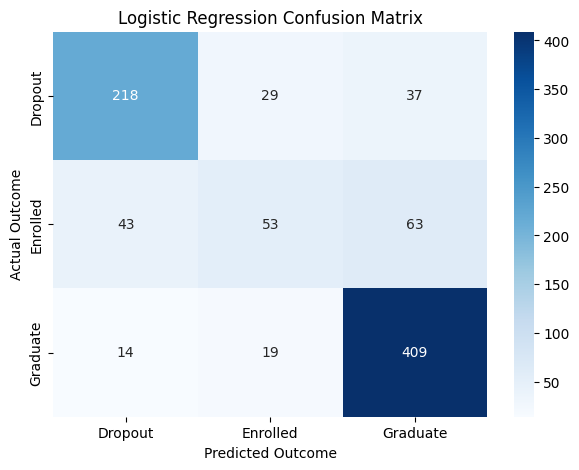

In [28]:
plt.figure(figsize=(7, 5))

cm = confusion_matrix(
    y_test,
    log_pred,
    labels=['Dropout', 'Enrolled', 'Graduate']
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dropout', 'Enrolled', 'Graduate'],
    yticklabels=['Dropout', 'Enrolled', 'Graduate']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')

plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')

print("RANDOM FOREST RESULTS")
print("=" * 50)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Macro F1 Score: {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS
Accuracy: 0.7740
Macro F1 Score: 0.7001

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.58      0.38      0.46       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



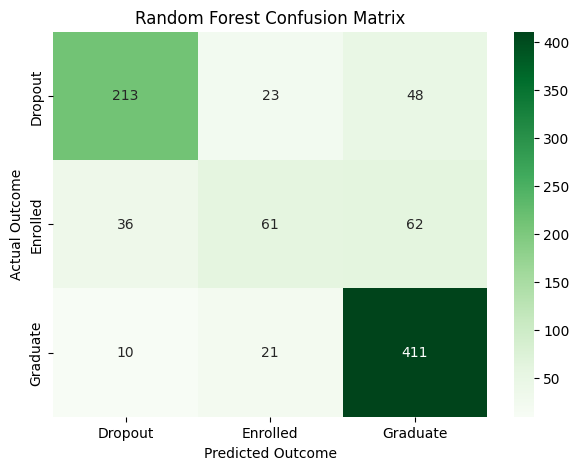

In [30]:
plt.figure(figsize=(7, 5))

cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=['Dropout', 'Enrolled', 'Graduate']
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Dropout', 'Enrolled', 'Graduate'],
    yticklabels=['Dropout', 'Enrolled', 'Graduate']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')

plt.show()

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
).head(15)

feature_importance

,Feature,Importance
30,Curricular units 2nd sem (approved),0.122366
31,Curricular units 2nd sem (grade),0.096545
24,Curricular units 1st sem (approved),0.070141
25,Curricular units 1st sem (grade),0.064424
12,Admission grade,0.047101
29,Curricular units 2nd sem (evaluations),0.045082
6,Previous qualification (grade),0.042404
19,Age at enrollment,0.042298
23,Curricular units 1st sem (evaluations),0.041173
16,Tuition fees up to date,0.038329


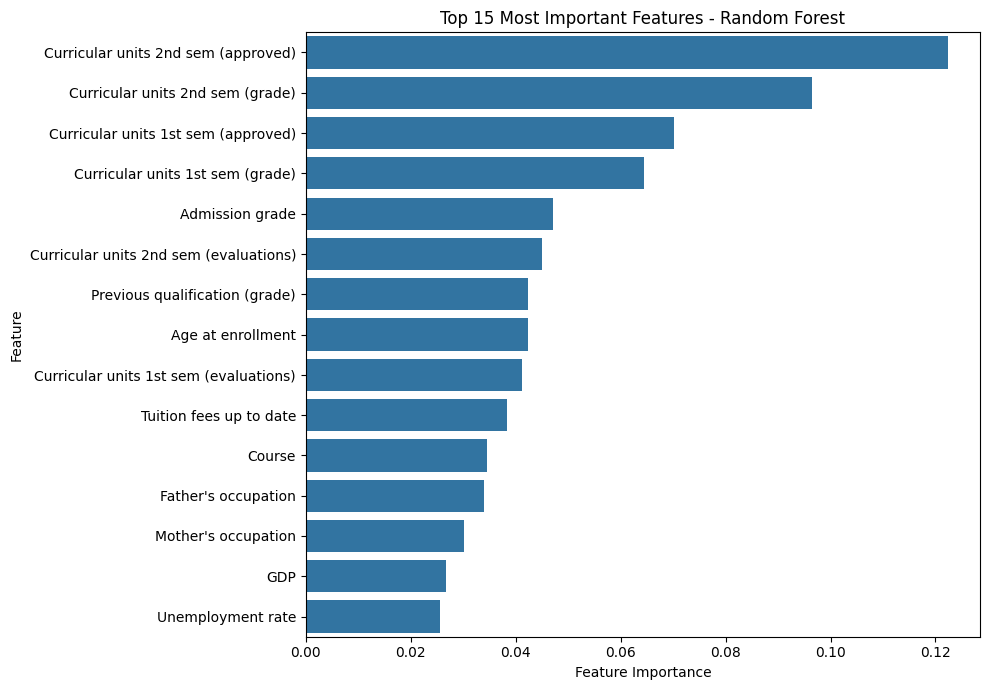

In [32]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Most Important Features - Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Random Forest Feature Importance

The Random Forest model identified academic performance as the most influential source of predictive information. The number of second-semester curricular units approved was the most important feature, followed by second-semester grade, first-semester units approved, and first-semester grade.

Admission grade, age at enrollment, tuition fee status, and previous academic performance also contributed to the model. These findings are consistent with the exploratory analysis and suggest that a combination of current academic progress, prior performance, and student circumstances can help predict academic outcomes.

In [33]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['Dropout' 'Enrolled' 'Graduate']


In [34]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train_encoded)

xgb_pred_encoded = xgb_model.predict(X_test)
xgb_pred = label_encoder.inverse_transform(xgb_pred_encoded)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='macro')

print("XGBOOST RESULTS")
print("=" * 50)

print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Macro F1 Score: {xgb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBOOST RESULTS
Accuracy: 0.7706
Macro F1 Score: 0.7052

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.74      0.77       284
    Enrolled       0.54      0.44      0.48       159
    Graduate       0.81      0.91      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



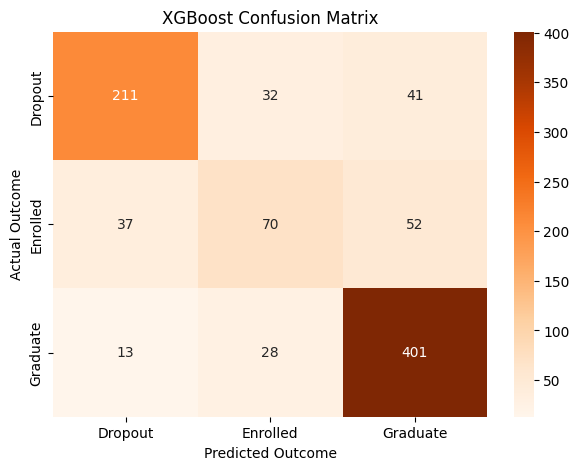

In [35]:
plt.figure(figsize=(7, 5))

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred,
    labels=['Dropout', 'Enrolled', 'Graduate']
)

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Dropout', 'Enrolled', 'Graduate'],
    yticklabels=['Dropout', 'Enrolled', 'Graduate']
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')

plt.show()

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

y_train_nn = label_encoder.transform(y_train)
y_test_nn = label_encoder.transform(y_test)

print("Neural network data prepared.")
print("Input features:", X_train_scaled.shape[1])
print("Number of classes:", len(label_encoder.classes_))

Neural network data prepared.
Input features: 36
Number of classes: 3


In [37]:
nn_model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(64, activation='relu'),
    Dropout(0.20),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,171 (59.26 KB)

 Trainable params: 15,171 (59.26 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled,
    y_train_nn,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8131 - loss: 0.4644 - val_accuracy: 0.7867 - val_loss: 0.5693
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8153 - loss: 0.4491 - val_accuracy: 0.7754 - val_loss: 0.5811
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8100 - loss: 0.4569 - val_accuracy: 0.7881 - val_loss: 0.5773
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8174 - loss: 0.4440 - val_accuracy: 0.7768 - val_loss: 0.5852
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8146 - loss: 0.4411 - val_accuracy: 0.7825 - val_loss: 0.5885
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8259 - loss: 0.4382 - val_accuracy: 0.7825 - val_loss: 0.5896
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8280 - loss: 0.4309 - val_accuracy: 0.7910 - val_loss: 0.5974
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8234 - loss: 0.4347 - val_accuracy: 0.7924 - v

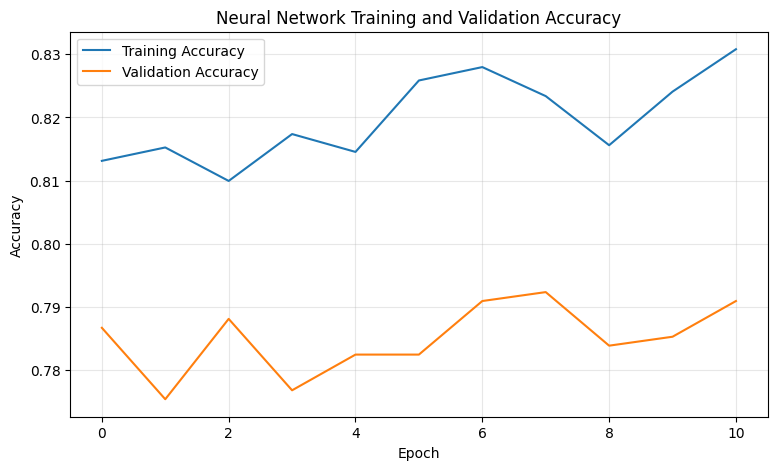

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Neural Network Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

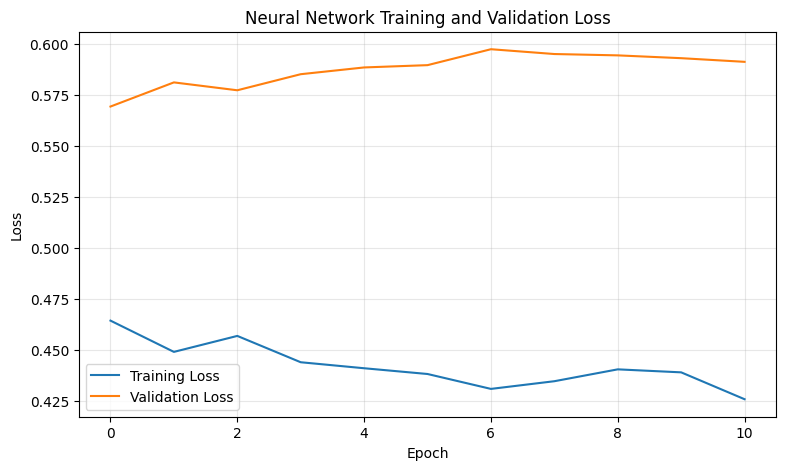

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Neural Network Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
nn_probabilities = nn_model.predict(X_test_scaled)

nn_pred_encoded = np.argmax(nn_probabilities, axis=1)
nn_pred = label_encoder.inverse_transform(nn_pred_encoded)

nn_accuracy = accuracy_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred, average='macro')

print("NEURAL NETWORK RESULTS")
print("=" * 50)

print(f"Accuracy: {nn_accuracy:.4f}")
print(f"Macro F1 Score: {nn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, nn_pred))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NEURAL NETWORK RESULTS
Accuracy: 0.7559
Macro F1 Score: 0.6838

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
    Enrolled       0.47      0.38      0.42       159
    Graduate       0.80      0.89      0.84       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.68       885
weighted avg       0.75      0.76      0.75       885



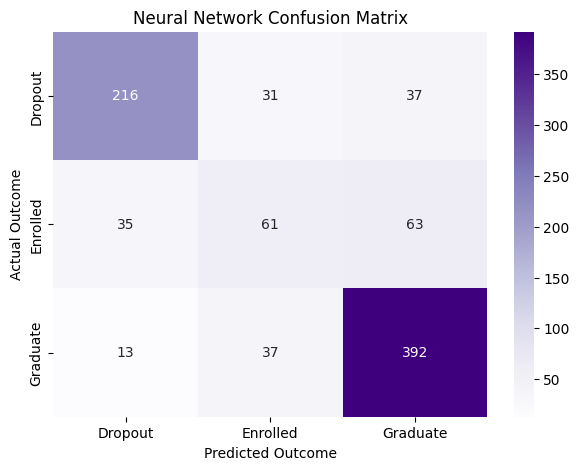

In [44]:
plt.figure(figsize=(7, 5))

cm_nn = confusion_matrix(
    y_test,
    nn_pred,
    labels=['Dropout', 'Enrolled', 'Graduate']
)

sns.heatmap(
    cm_nn,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Dropout', 'Enrolled', 'Graduate'],
    yticklabels=['Dropout', 'Enrolled', 'Graduate']
)

plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')

plt.show()

In [45]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Neural Network'
    ],
    'Accuracy': [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy,
        nn_accuracy
    ],
    'Macro F1': [
        log_f1,
        rf_f1,
        xgb_f1,
        nn_f1
    ]
})

model_results = model_results.sort_values(
    by='Macro F1',
    ascending=False
).reset_index(drop=True)

model_results

,Model,Accuracy,Macro F1
0,XGBoost,0.770621,0.705193
1,Random Forest,0.774011,0.700078
2,Neural Network,0.755932,0.683778
3,Logistic Regression,0.768362,0.682601


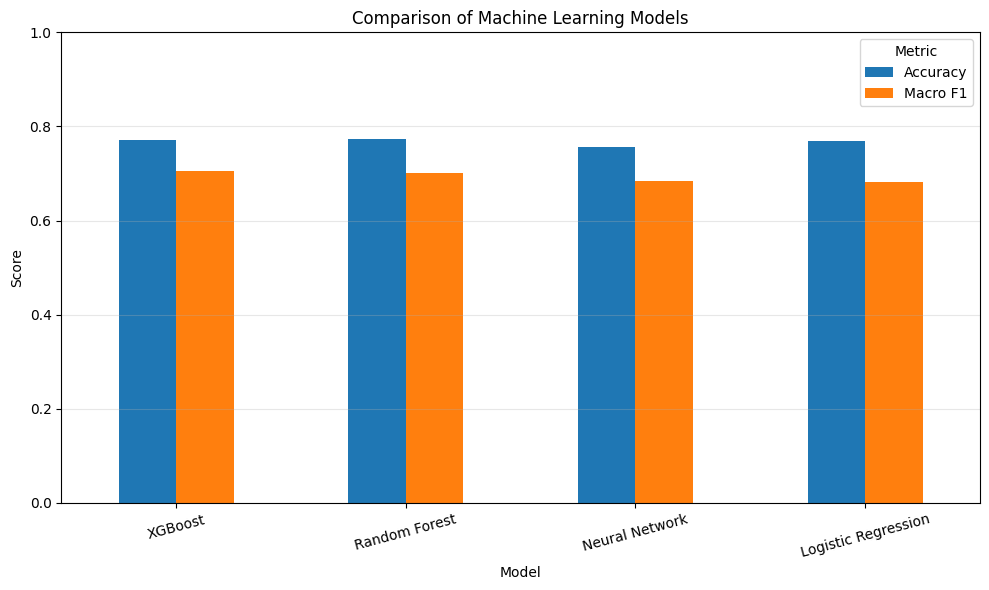

In [46]:
comparison_plot = model_results.set_index('Model')[
    ['Accuracy', 'Macro F1']
]

ax = comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Comparison of Machine Learning Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Model Comparison

Four classification approaches were evaluated: Logistic Regression, Random Forest, XGBoost, and a feedforward Neural Network.

The models produced relatively similar overall accuracies, ranging from approximately 75.6% to 77.4%. Random Forest achieved the highest overall accuracy at 77.40%, while XGBoost achieved the highest Macro F1 score at 0.7052.

XGBoost also achieved the strongest recall for the Enrolled class at 44%, compared with 38% for Random Forest, 38% for the Neural Network, and 33% for Logistic Regression. This is important because the Enrolled class contains fewer observations and was consistently the most difficult outcome to classify.

Considering performance across all three classes rather than accuracy alone, XGBoost provided the strongest overall balance.

## Neural Network Findings

A feedforward neural network was developed with three hidden Dense layers containing 128, 64, and 32 neurons. Dropout layers were incorporated to reduce overfitting, and early stopping was used to monitor validation loss.

The neural network achieved an accuracy of 75.59% and a Macro F1 score of 0.6838. Although training accuracy increased to approximately 83%, validation accuracy remained around 78–79%. The gap between training and validation performance, together with the validation-loss pattern, suggests some overfitting.

For this structured tabular dataset, the tree-based ensemble models ultimately generalized better than the neural network.

# Conclusion

This project investigated whether student academic outcomes could be predicted from demographic, socioeconomic, enrollment, and academic-performance characteristics.

Exploratory analysis showed that academic progress was strongly associated with student outcomes. In particular, the number of curricular units approved and student grades during the first and second semesters emerged as important indicators. Tuition fee status, scholarship status, admission grade, and age at enrollment also contributed useful information.

Four predictive approaches were evaluated: Logistic Regression, Random Forest, XGBoost, and a Neural Network. Random Forest achieved the highest accuracy of 77.40%, while XGBoost obtained the highest Macro F1 score of 0.7052 and performed better at identifying the more difficult Enrolled class.

Therefore, XGBoost was selected as the strongest overall model when balanced performance across all three academic outcomes was considered.

The results demonstrate the potential of machine learning to identify patterns associated with student progression. Such models could potentially support educational institutions in recognizing students who may require additional academic support. However, predictions should be interpreted carefully and used as decision-support tools rather than as replacements for human judgment.